<a href="https://colab.research.google.com/github/yashvimittal0-tech/ITA-Yashvi-/blob/main/project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

# Task
Analyze the breast cancer dataset ("uciml/breast-cancer-wisconsin-data") by performing feature normalization, PCA for dimensionality reduction, training and comparing supervised models (SVM, Logistic Regression, KNN) with both full and PCA-reduced features, visualizing decision boundaries, and summarizing the findings.

## Load and Prepare Data

### Subtask:
Load the breast cancer dataset, separate features (X) and target (y), and handle any initial data cleaning or preprocessing if necessary. This will also involve encoding the target variable if it's categorical.


**Reasoning**:
To begin loading and preparing the data, I will import the pandas library and list the contents of the `path` directory to identify the dataset file, as per the instructions.



In [ ]:
import pandas as pd
import os

# List contents of the 'path' directory to find the CSV file
file_list = os.listdir(path)
print("Files in dataset directory:", file_list)

NameError: name 'path' is not defined

**Reasoning**:
The 'path' variable is undefined because the previous cell that defines it has not been executed. To fix this `NameError` and ensure the current code block runs successfully, I need to include the `kagglehub` import and the definition of the `path` variable within this cell.



In [ ]:
import pandas as pd
import os
import kagglehub

# Download latest version to ensure 'path' is defined
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

# List contents of the 'path' directory to find the CSV file
file_list = os.listdir(path)
print("Files in dataset directory:", file_list)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Files in dataset directory: ['data.csv']


**Reasoning**:
Now that the dataset file `data.csv` has been identified, I will load it into a pandas DataFrame and display the first 5 rows to inspect its structure and content, as per the instructions.



In [ ]:
csv_file_path = os.path.join(path, file_list[0])
df = pd.read_csv(csv_file_path)
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_

**Reasoning**:
Based on the instructions, I need to separate the features (X) and the target variable (y) from the DataFrame. I will identify the 'diagnosis' column as the target, and drop the 'id' and 'Unnamed: 32' columns (as it seems to contain only NaNs) from the features. Then, I will encode the categorical target variable 'diagnosis' into a numerical format.



In [ ]:
from sklearn.preprocessing import LabelEncoder

# Drop 'id' and 'Unnamed: 32' columns
df = df.drop(columns=['id', 'Unnamed: 32'])

# Separate features (X) and target (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Encode the target variable 'y'
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("First 5 rows of features (X):")
print(X.head())
print("\nFirst 5 rows of encoded target (y_encoded):")
print(y_encoded[:5])
print("\nMapping of diagnosis labels:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

First 5 rows of features (X):
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  radius_worst  texture_worst  p

## Feature Normalization and Correlation Analysis

### Subtask:
Normalize the features using a suitable scaler (e.g., StandardScaler). Then, calculate and visualize the correlation matrix of the normalized features to understand relationships between them.


**Reasoning**:
To normalize the features and visualize their correlation, I will import `StandardScaler` from scikit-learn, `matplotlib.pyplot` for plotting, and `seaborn` for enhanced visualizations. I will then instantiate the scaler, fit and transform the feature matrix `X` to create `X_scaled`, calculate its correlation matrix, and display it as a heatmap.



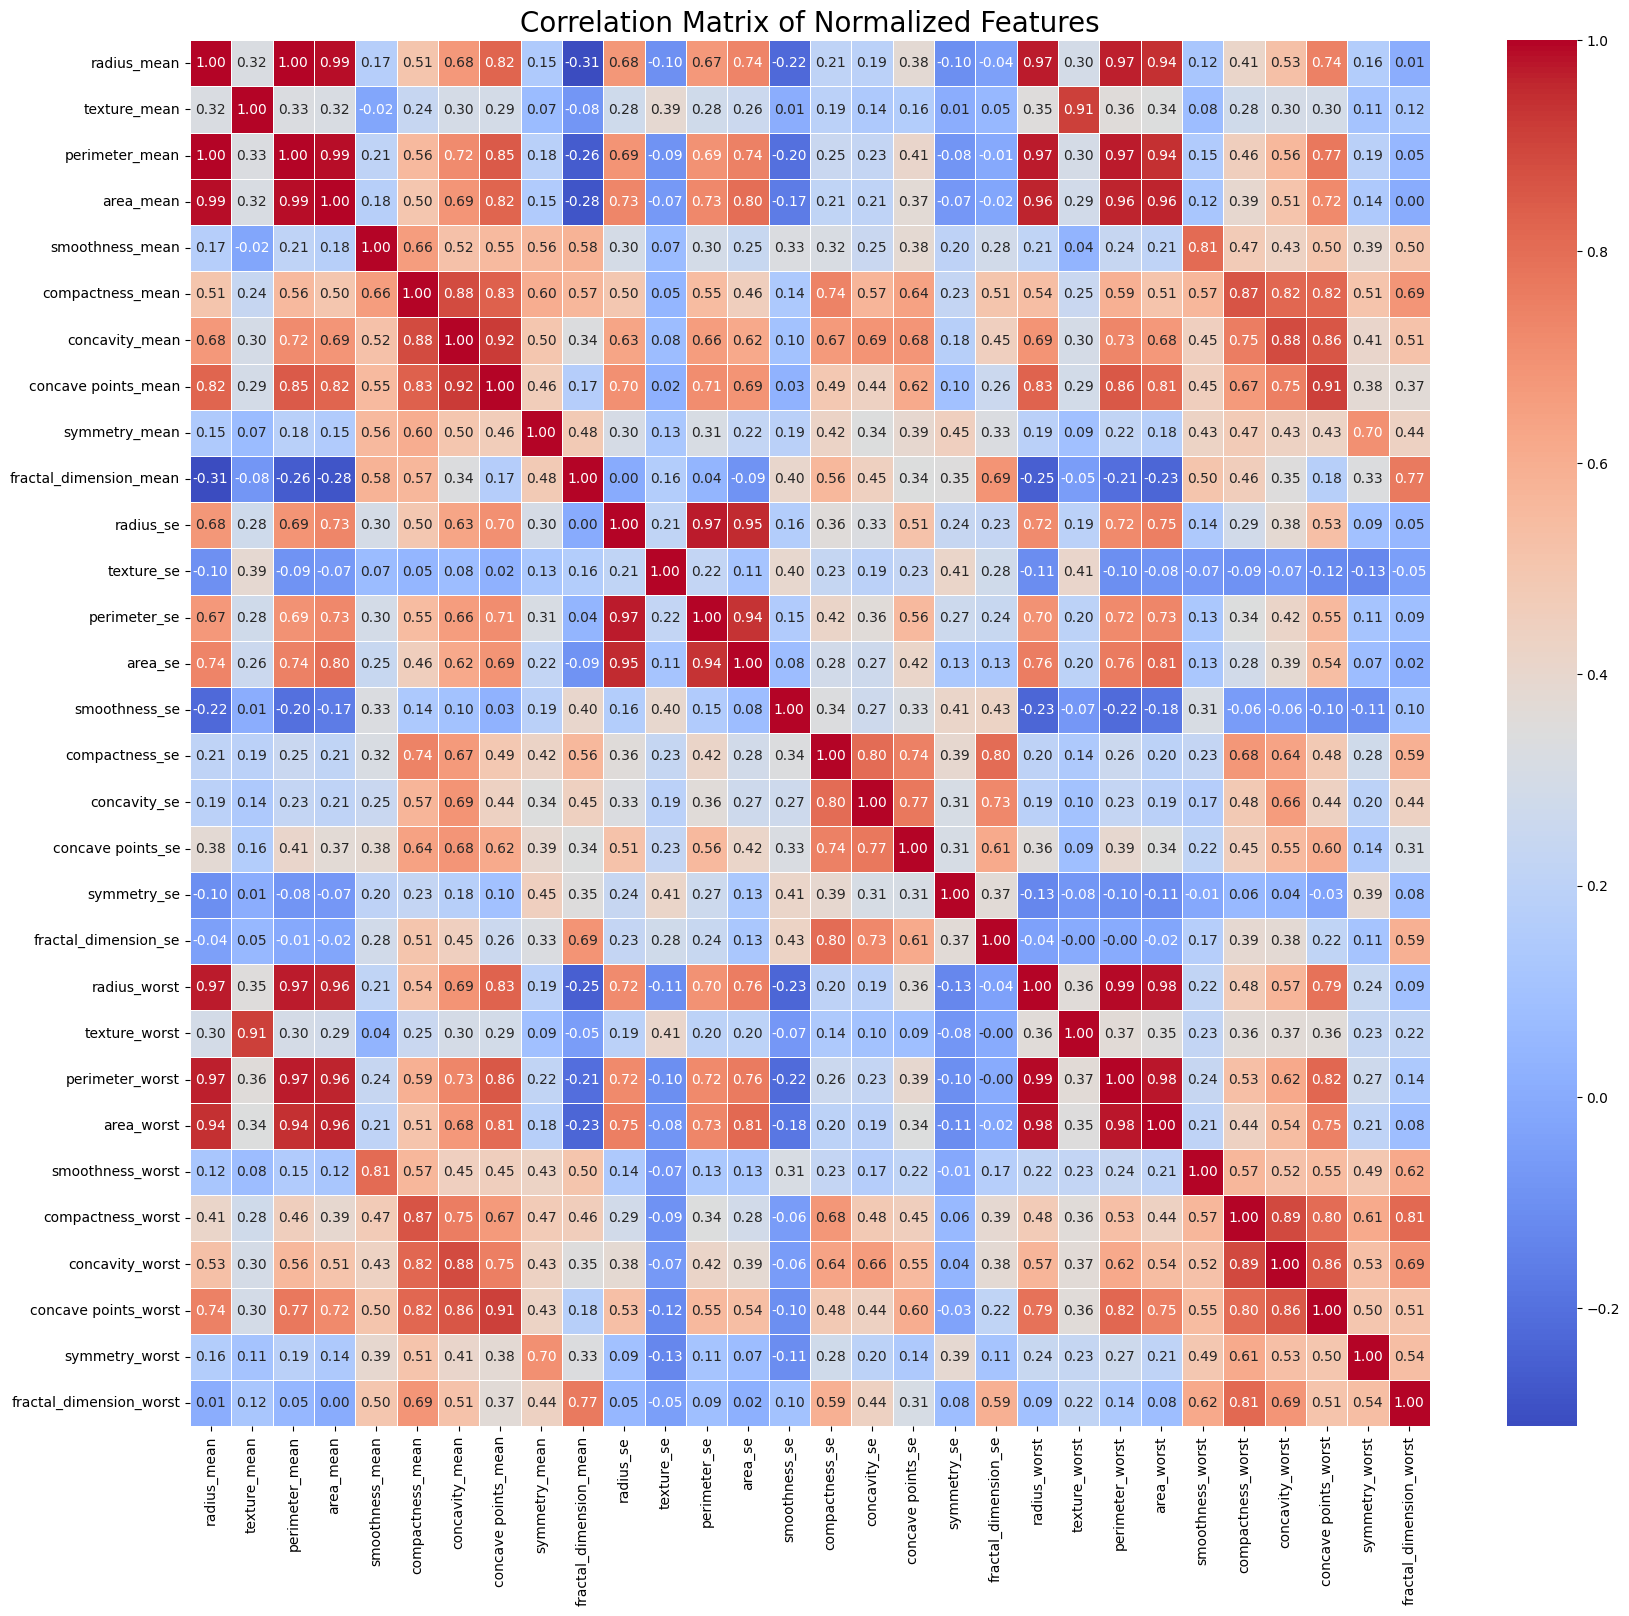

In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Instantiate StandardScaler
scaler = StandardScaler()

# Apply the scaler to features X and store in X_scaled
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Calculate the correlation matrix of X_scaled
correlation_matrix = X_scaled.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Normalized Features', fontsize=20)
plt.show()

## Apply Principal Component Analysis (PCA)

### Subtask:
Apply PCA to the normalized features to reduce dimensionality. We will prepare two sets of PCA-transformed data: one for general dimensionality reduction (e.g., selecting components that explain a high percentage of variance) and another specifically for 2 components for visualization purposes.


**Reasoning**:
To apply PCA, I will import `PCA` from `sklearn.decomposition`, instantiate it, and fit it to the `X_scaled` data. Then, I will plot the explained variance ratio to identify the number of components needed to capture a significant percentage of variance (e.g., 95%).



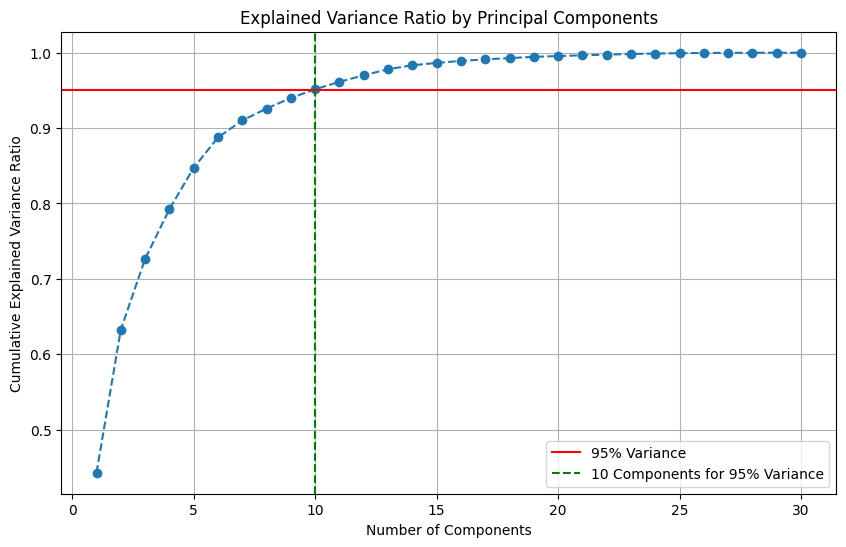

Number of components to explain 95% variance: 10


In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# Instantiate PCA without specifying n_components to get all components
pca_full = PCA()
pca_full.fit(X_scaled)

# Calculate cumulative explained variance ratio
cum_var_exp = np.cumsum(pca_full.explained_variance_ratio_)

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_var_exp) + 1), cum_var_exp, marker='o', linestyle='--')
plt.title('Explained Variance Ratio by Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)

# Add a horizontal line for 95% variance and find the number of components
variance_threshold = 0.95
num_components_95 = np.where(cum_var_exp >= variance_threshold)[0][0] + 1
plt.axhline(y=variance_threshold, color='r', linestyle='-', label=f'{variance_threshold*100:.0f}% Variance')
plt.axvline(x=num_components_95, color='g', linestyle='--', label=f'{num_components_95} Components for {variance_threshold*100:.0f}% Variance')
plt.legend()
plt.show()

print(f"Number of components to explain {variance_threshold*100:.0f}% variance: {num_components_95}")

**Reasoning**:
Now that the optimal number of components for 95% variance has been identified (10 components), I will instantiate two new PCA objects: one with `n_components=10` to create `X_pca_high_variance` and another with `n_components=2` to create `X_pca_2d`. Both will be fitted and transformed using the `X_scaled` data, and their shapes will be printed to confirm the dimensionality reduction.



In [ ]:
import pandas as pd

# PCA for high variance (95% variance)
pca_high_variance = PCA(n_components=num_components_95)
X_pca_high_variance = pd.DataFrame(pca_high_variance.fit_transform(X_scaled), columns=[f'PC_{i+1}' for i in range(num_components_95)])

# PCA for 2 components (for visualization)
pca_2d = PCA(n_components=2)
X_pca_2d = pd.DataFrame(pca_2d.fit_transform(X_scaled), columns=['PC1', 'PC2'])

print(f"Shape of X_pca_high_variance: {X_pca_high_variance.shape}")
print(f"Shape of X_pca_2d: {X_pca_2d.shape}")

Shape of X_pca_high_variance: (569, 10)
Shape of X_pca_2d: (569, 2)


## Train Supervised Models (Full Features)

### Subtask:
Train Support Vector Machine (SVM), Logistic Regression, and K-Nearest Neighbors (KNN) models using the full set of normalized features. Evaluate their performance using appropriate metrics (e.g., accuracy, precision, recall, F1-score).


**Reasoning**:
To begin training and evaluating the models, I will first split the `X_scaled` features and `y_encoded` target variable into training and testing sets. Then, I will import the necessary model classes and evaluation metrics from scikit-learn. Finally, I will initialize a dictionary to store the performance metrics for each model.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Split the data into training and testing sets
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# Dictionary to store performance metrics for models trained with full features
full_features_metrics = {}

print("Data split into training and testing sets.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print("Required libraries imported and full_features_metrics dictionary initialized.")

Data split into training and testing sets.
X_train_scaled shape: (455, 30)
X_test_scaled shape: (114, 30)
Required libraries imported and full_features_metrics dictionary initialized.


**Reasoning**:
I will now initialize, train, predict, and evaluate each of the three models (SVM, Logistic Regression, and KNN) using the full set of scaled features. I will then calculate and print their performance metrics (accuracy, precision, recall, F1-score) and store them in the `full_features_metrics` dictionary for comparison.



In [ ]:
print("\n--- Training and Evaluating Models with Full Features ---")

# --- Support Vector Machine (SVM) ---
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

full_features_metrics['SVM'] = {
    'Accuracy': accuracy_svm,
    'Precision': precision_svm,
    'Recall': recall_svm,
    'F1-Score': f1_svm
}

print("\nSVM Model Performance (Full Features):")
print(f"  Accuracy: {accuracy_svm:.4f}")
print(f"  Precision: {precision_svm:.4f}")
print(f"  Recall: {recall_svm:.4f}")
print(f"  F1-Score: {f1_svm:.4f}")

# --- Logistic Regression ---
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg_model.predict(X_test_scaled)

accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg, average='weighted')
recall_log_reg = recall_score(y_test, y_pred_log_reg, average='weighted')
f1_log_reg = f1_score(y_test, y_pred_log_reg, average='weighted')

full_features_metrics['Logistic Regression'] = {
    'Accuracy': accuracy_log_reg,
    'Precision': precision_log_reg,
    'Recall': recall_log_reg,
    'F1-Score': f1_log_reg
}

print("\nLogistic Regression Model Performance (Full Features):")
print(f"  Accuracy: {accuracy_log_reg:.4f}")
print(f"  Precision: {precision_log_reg:.4f}")
print(f"  Recall: {recall_log_reg:.4f}")
print(f"  F1-Score: {f1_log_reg:.4f}")

# --- K-Nearest Neighbors (KNN) ---
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average='weighted')
recall_knn = recall_score(y_test, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

full_features_metrics['KNN'] = {
    'Accuracy': accuracy_knn,
    'Precision': precision_knn,
    'Recall': recall_knn,
    'F1-Score': f1_knn
}

print("\nKNN Model Performance (Full Features):")
print(f"  Accuracy: {accuracy_knn:.4f}")
print(f"  Precision: {precision_knn:.4f}")
print(f"  Recall: {recall_knn:.4f}")
print(f"  F1-Score: {f1_knn:.4f}")

print("\nAll models trained and evaluated. Metrics stored in 'full_features_metrics'.")


--- Training and Evaluating Models with Full Features ---

SVM Model Performance (Full Features):
  Accuracy: 0.9737
  Precision: 0.9737
  Recall: 0.9737
  F1-Score: 0.9736

Logistic Regression Model Performance (Full Features):
  Accuracy: 0.9737
  Precision: 0.9737
  Recall: 0.9737
  F1-Score: 0.9736

KNN Model Performance (Full Features):
  Accuracy: 0.9474
  Precision: 0.9474
  Recall: 0.9474
  F1-Score: 0.9474

All models trained and evaluated. Metrics stored in 'full_features_metrics'.


## Train Supervised Models (PCA-Reduced Features)

### Subtask:
Train Support Vector Machine (SVM), Logistic Regression, and K-Nearest Neighbors (KNN) models using the PCA-reduced features. Evaluate their performance to compare with the full-feature models.


**Reasoning**:
To train and evaluate the models with PCA-reduced features, I will first split the `X_pca_high_variance` features and `y_encoded` target variable into training and testing sets. Then, I will initialize a dictionary to store the performance metrics and proceed to train, predict, and evaluate SVM, Logistic Regression, and KNN models, storing their results.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Split the PCA-reduced data into training and testing sets
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca_high_variance, y_encoded, test_size=0.2, random_state=42)

# 2. Dictionary to store performance metrics for models trained with PCA-reduced features
pca_features_metrics = {}

print("Data split into training and testing sets for PCA-reduced features.")
print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"X_test_pca shape: {X_test_pca.shape}")
print("pca_features_metrics dictionary initialized.")

print("\n--- Training and Evaluating Models with PCA-Reduced Features ---")

# 3. --- Support Vector Machine (SVM) ---
svm_pca_model = SVC(random_state=42)
svm_pca_model.fit(X_train_pca, y_train)
y_pred_svm_pca = svm_pca_model.predict(X_test_pca)

# 4. Calculate and store SVM metrics
accuracy_svm_pca = accuracy_score(y_test, y_pred_svm_pca)
precision_svm_pca = precision_score(y_test, y_pred_svm_pca, average='weighted')
recall_svm_pca = recall_score(y_test, y_pred_svm_pca, average='weighted')
f1_svm_pca = f1_score(y_test, y_pred_svm_pca, average='weighted')

pca_features_metrics['SVM'] = {
    'Accuracy': accuracy_svm_pca,
    'Precision': precision_svm_pca,
    'Recall': recall_svm_pca,
    'F1-Score': f1_svm_pca
}

print("\nSVM Model Performance (PCA-Reduced Features):")
print(f"  Accuracy: {accuracy_svm_pca:.4f}")
print(f"  Precision: {precision_svm_pca:.4f}")
print(f"  Recall: {recall_svm_pca:.4f}")
print(f"  F1-Score: {f1_svm_pca:.4f}")

# 5. --- Logistic Regression ---
log_reg_pca_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_pca_model.fit(X_train_pca, y_train)
y_pred_log_reg_pca = log_reg_pca_model.predict(X_test_pca)

# 6. Calculate and store Logistic Regression metrics
accuracy_log_reg_pca = accuracy_score(y_test, y_pred_log_reg_pca)
precision_log_reg_pca = precision_score(y_test, y_pred_log_reg_pca, average='weighted')
recall_log_reg_pca = recall_score(y_test, y_pred_log_reg_pca, average='weighted')
f1_log_reg_pca = f1_score(y_test, y_pred_log_reg_pca, average='weighted')

pca_features_metrics['Logistic Regression'] = {
    'Accuracy': accuracy_log_reg_pca,
    'Precision': precision_log_reg_pca,
    'Recall': recall_log_reg_pca,
    'F1-Score': f1_log_reg_pca
}

print("\nLogistic Regression Model Performance (PCA-Reduced Features):")
print(f"  Accuracy: {accuracy_log_reg_pca:.4f}")
print(f"  Precision: {precision_log_reg_pca:.4f}")
print(f"  Recall: {recall_log_reg_pca:.4f}")
print(f"  F1-Score: {f1_log_reg_pca:.4f}")

# 7. --- K-Nearest Neighbors (KNN) ---
knn_pca_model = KNeighborsClassifier(n_neighbors=5)
knn_pca_model.fit(X_train_pca, y_train)
y_pred_knn_pca = knn_pca_model.predict(X_test_pca)

# 8. Calculate and store KNN metrics
accuracy_knn_pca = accuracy_score(y_test, y_pred_knn_pca)
precision_knn_pca = precision_score(y_test, y_pred_knn_pca, average='weighted')
recall_knn_pca = recall_score(y_test, y_pred_knn_pca, average='weighted')
f1_knn_pca = f1_score(y_test, y_pred_knn_pca, average='weighted')

pca_features_metrics['KNN'] = {
    'Accuracy': accuracy_knn_pca,
    'Precision': precision_knn_pca,
    'Recall': recall_knn_pca,
    'F1-Score': f1_knn_pca
}

print("\nKNN Model Performance (PCA-Reduced Features):")
print(f"  Accuracy: {accuracy_knn_pca:.4f}")
print(f"  Precision: {precision_knn_pca:.4f}")
print(f"  Recall: {recall_knn_pca:.4f}")
print(f"  F1-Score: {f1_knn_pca:.4f}")

print("\nAll models trained and evaluated with PCA-reduced features. Metrics stored in 'pca_features_metrics'.")

Data split into training and testing sets for PCA-reduced features.
X_train_pca shape: (455, 10)
X_test_pca shape: (114, 10)
pca_features_metrics dictionary initialized.

--- Training and Evaluating Models with PCA-Reduced Features ---

SVM Model Performance (PCA-Reduced Features):
  Accuracy: 0.9737
  Precision: 0.9737
  Recall: 0.9737
  F1-Score: 0.9736

Logistic Regression Model Performance (PCA-Reduced Features):
  Accuracy: 0.9825
  Precision: 0.9825
  Recall: 0.9825
  F1-Score: 0.9825

KNN Model Performance (PCA-Reduced Features):
  Accuracy: 0.9561
  Precision: 0.9561
  Recall: 0.9561
  F1-Score: 0.9560

All models trained and evaluated with PCA-reduced features. Metrics stored in 'pca_features_metrics'.


## Compare Model Performance

### Subtask:
Compare the performance metrics (e.g., accuracy, precision, recall, F1-score) of all trained models, contrasting those trained with full features against those trained with PCA-reduced features. This will be presented in a clear, comparative format, possibly using a table or bar chart with legends.


**Reasoning**:
To compare the performance metrics, I will first consolidate the metrics from both `full_features_metrics` and `pca_features_metrics` into a pandas DataFrame. This will allow for easier manipulation and plotting of the data.



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Consolidate metrics into a single dictionary for easier DataFrame creation
all_metrics = {}
for model_name, metrics in full_features_metrics.items():
    for metric_name, value in metrics.items():
        all_metrics[f'{model_name} (Full) {metric_name}'] = value

for model_name, metrics in pca_features_metrics.items():
    for metric_name, value in metrics.items():
        all_metrics[f'{model_name} (PCA) {metric_name}'] = value

# Create a DataFrame from the consolidated metrics
metrics_df = pd.DataFrame(all_metrics, index=['Value']).T
metrics_df.index.name = 'Model_Feature_Metric'

# Extract model name, feature type, and metric type from the index
metrics_df[['Model', 'Feature_Type', 'Metric']] = metrics_df.index.str.extract(r'(.+?) \((Full|PCA)\) (.+)')
metrics_df = metrics_df.pivot_table(index=['Model', 'Feature_Type'], columns='Metric', values='Value')

print("Consolidated metrics DataFrame head:")
print(metrics_df.head())

Consolidated metrics DataFrame head:
Empty DataFrame
Columns: []
Index: []


**Reasoning**:
The previous attempt to create the `metrics_df` resulted in an empty DataFrame. To correctly consolidate and structure the metrics for comparison, I will create a list of dictionaries, each representing a row with model, feature type, metric name, and its value. This structured list will then be converted into a pandas DataFrame and pivoted to the desired format (Model and Feature Type as index, metrics as columns).



Consolidated metrics DataFrame head:
Metric                                    Accuracy  F1-Score  Precision  \
Model               Feature_Type                                          
KNN                 Full Features         0.947368  0.947368   0.947368   
                    PCA-Reduced Features  0.956140  0.956036   0.956088   
Logistic Regression Full Features         0.973684  0.973621   0.973719   
                    PCA-Reduced Features  0.982456  0.982456   0.982456   
SVM                 Full Features         0.973684  0.973621   0.973719   

Metric                                      Recall  
Model               Feature_Type                    
KNN                 Full Features         0.947368  
                    PCA-Reduced Features  0.956140  
Logistic Regression Full Features         0.973684  
                    PCA-Reduced Features  0.982456  
SVM                 Full Features         0.973684  


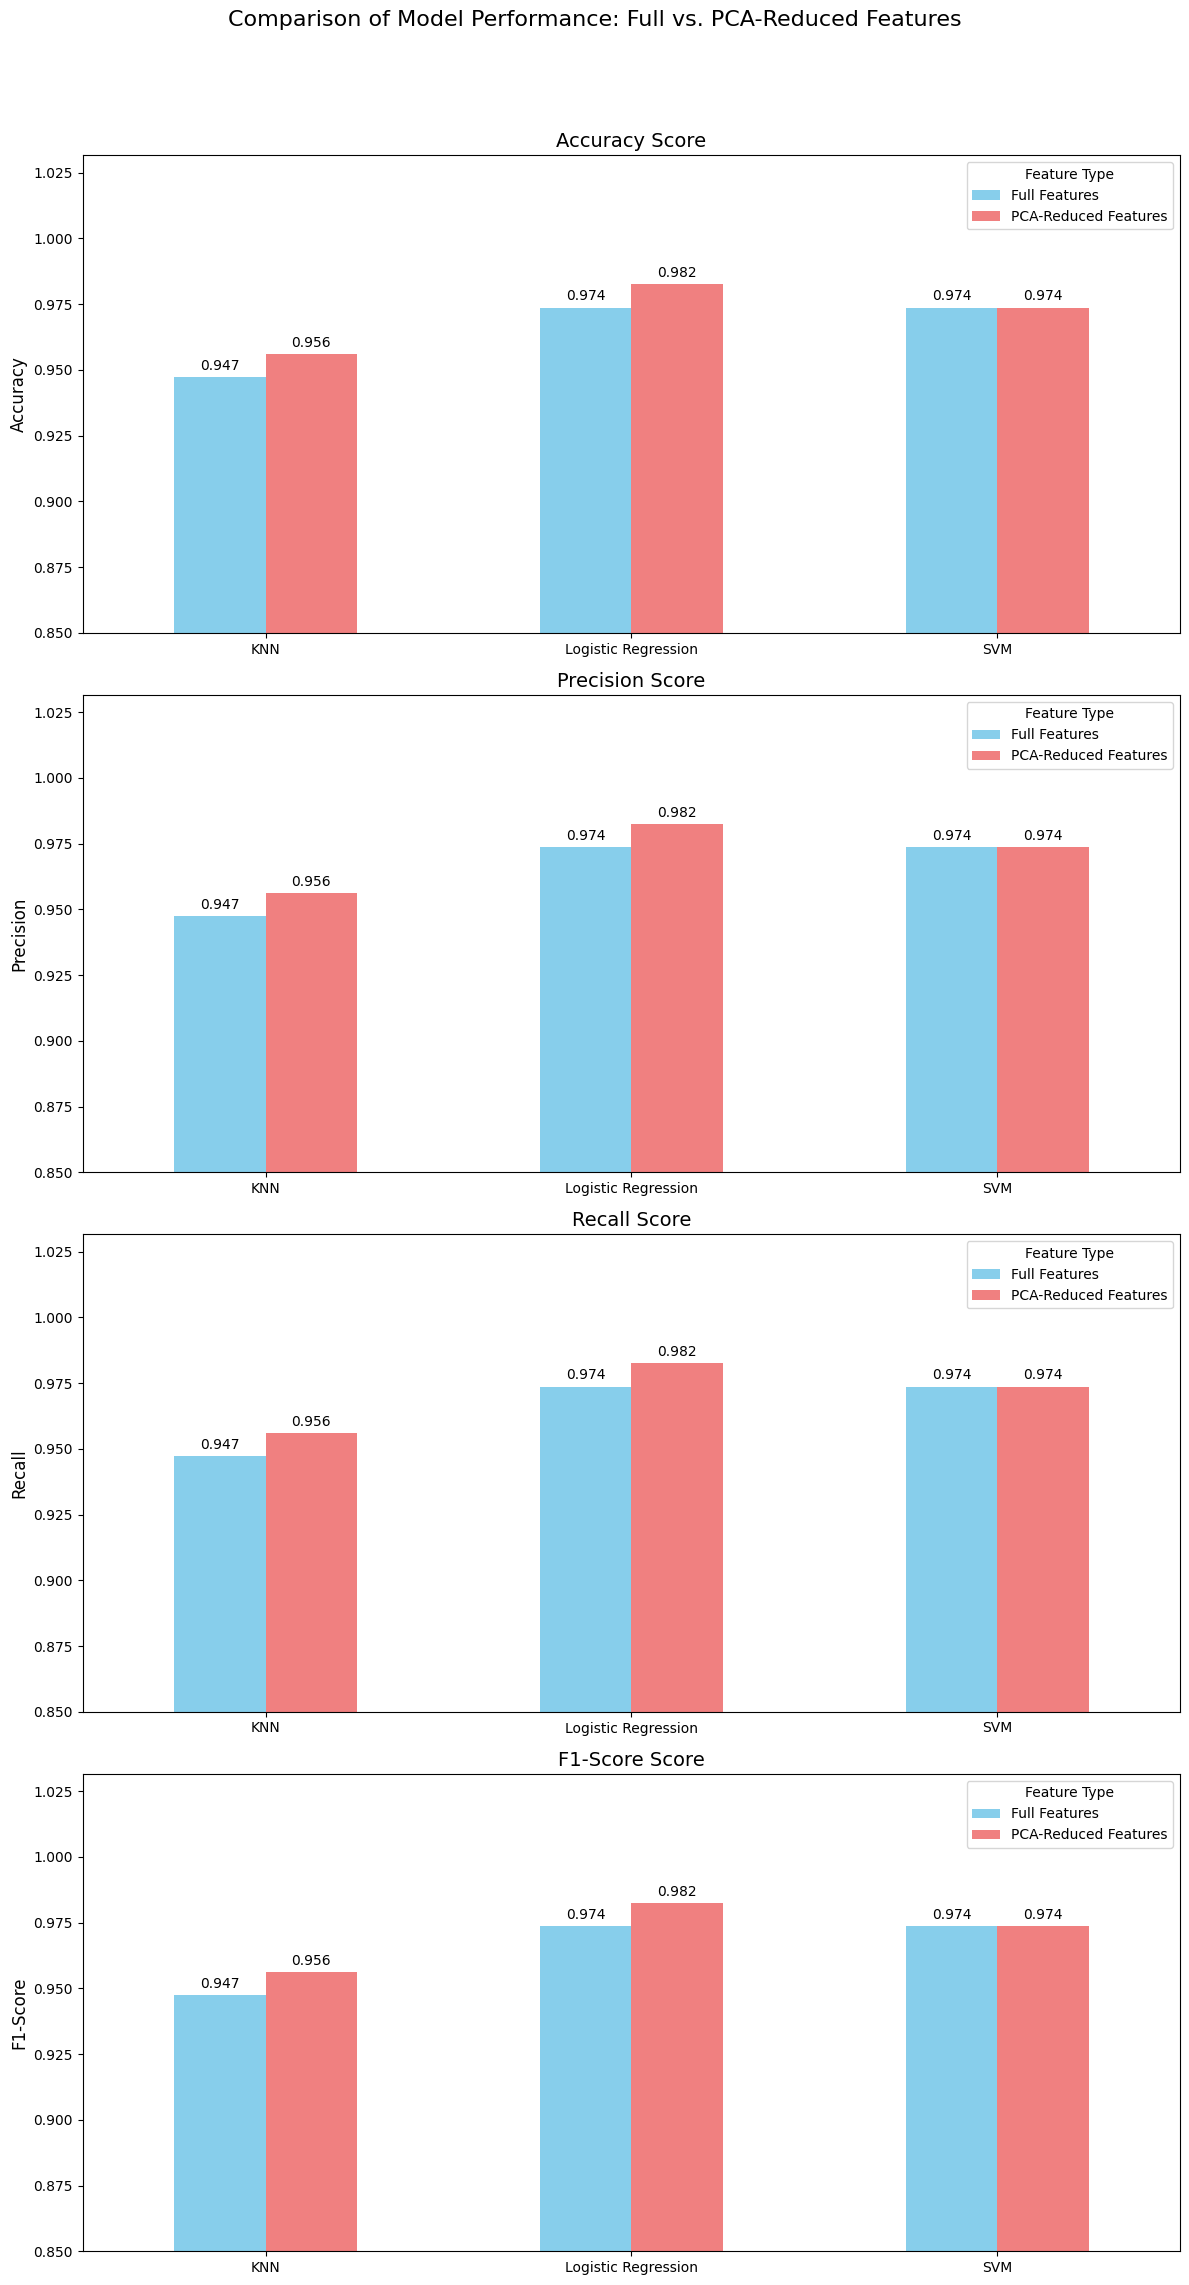

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prepare data for DataFrame creation
metrics_data = []

for model_name, metrics in full_features_metrics.items():
    for metric_name, value in metrics.items():
        metrics_data.append({
            'Model': model_name,
            'Feature_Type': 'Full Features',
            'Metric': metric_name,
            'Value': value
        })

for model_name, metrics in pca_features_metrics.items():
    for metric_name, value in metrics.items():
        metrics_data.append({
            'Model': model_name,
            'Feature_Type': 'PCA-Reduced Features',
            'Metric': metric_name,
            'Value': value
        })

# Create a DataFrame from the collected data
metrics_df = pd.DataFrame(metrics_data)

# Pivot the DataFrame to have metrics as columns and Model/Feature_Type as index
metrics_df = metrics_df.pivot_table(index=['Model', 'Feature_Type'], columns='Metric', values='Value')

print("Consolidated metrics DataFrame head:")
print(metrics_df.head())

# Plotting the metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
n_metrics = len(metrics_to_plot)

fig, axes = plt.subplots(nrows=n_metrics, ncols=1, figsize=(12, 6 * n_metrics))
fig.suptitle('Comparison of Model Performance: Full vs. PCA-Reduced Features', fontsize=16)

# Define colors for full and PCA features
colors = {'Full Features': 'skyblue', 'PCA-Reduced Features': 'lightcoral'}

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]

    # Extract data for the current metric
    metric_data = metrics_df[metric].unstack(level='Feature_Type')

    # Plot bars for each model and feature type
    metric_data.plot(kind='bar', ax=ax, color=[colors[col] for col in metric_data.columns])

    ax.set_title(f'{metric} Score', fontsize=14)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xlabel('') # Remove default x-label to use custom labels below
    ax.set_xticklabels(metric_data.index, rotation=0)
    ax.legend(title='Feature Type')
    ax.set_ylim(bottom=0.85) # Adjust y-axis limit to highlight differences

    # Add value labels on top of the bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

## Visualize Decision Boundaries

### Subtask:
Using the 2D PCA projection, visualize the decision boundaries for at least one of the best-performing models (e.g., SVM or Logistic Regression) to illustrate how the model separates classes in a reduced feature space. Ensure legends are included.


**Reasoning**:
To visualize the decision boundaries, I will retrain the Logistic Regression model using the 2-component PCA data (`X_pca_2d`) and the encoded target variable (`y_encoded`). I will then create a meshgrid based on the ranges of the two principal components, predict class labels across this grid, and finally plot the decision boundaries using `plt.contourf` along with the actual data points using `plt.scatter`.



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


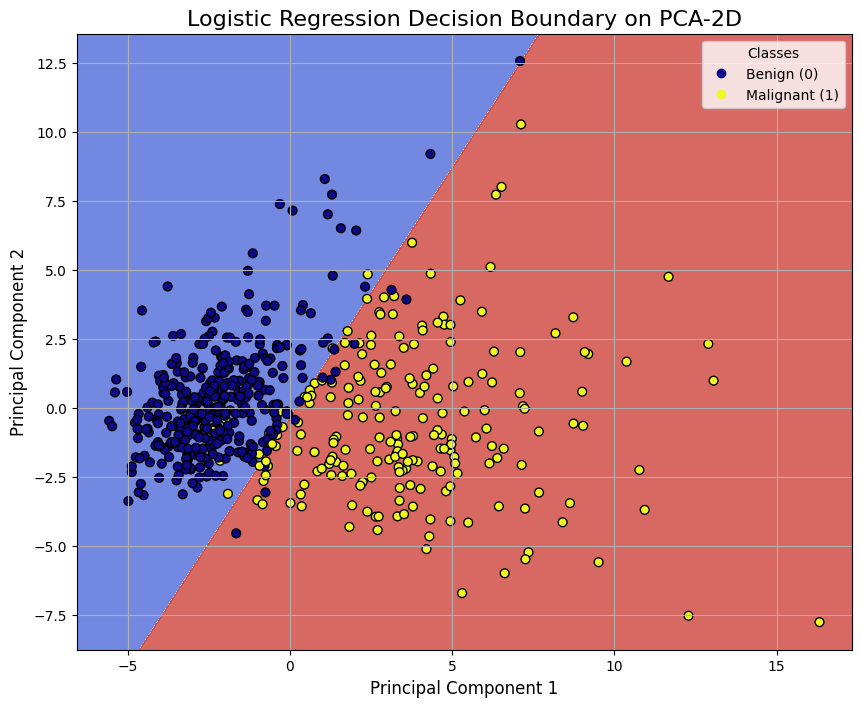

In [ ]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

# 1. Choose Logistic Regression (one of the best performing) and re-train it on X_pca_2d
log_reg_pca_2d = LogisticRegression(random_state=42)
log_reg_pca_2d.fit(X_pca_2d, y_encoded)

# 2. Create a meshgrid to plot the decision boundaries
# Determine min and max values for PC1 and PC2 from X_pca_2d with padding
x_min, x_max = X_pca_2d['PC1'].min() - 1, X_pca_2d['PC1'].max() + 1
y_min, y_max = X_pca_2d['PC2'].min() - 1, X_pca_2d['PC2'].max() + 1

h = .02 # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Flatten grid points and combine them for prediction
meshgrid_points = np.c_[xx.ravel(), yy.ravel()]

# 3. Predict the class labels for each point in the meshgrid
Z = log_reg_pca_2d.predict(meshgrid_points)
Z = Z.reshape(xx.shape)

# 4. Create a contour plot of the decision boundaries
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

# 5. Create a scatter plot of the actual X_pca_2d points
scatter = plt.scatter(X_pca_2d['PC1'], X_pca_2d['PC2'], c=y_encoded, cmap=plt.cm.plasma, s=40, edgecolors='k')

# 6. Add labels and title
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.title('Logistic Regression Decision Boundary on PCA-2D', fontsize=16)

# 7. Include a legend to distinguish between classes
# Create custom legend handles and labels
handles, labels = scatter.legend_elements()
legend_labels = ['Benign (0)', 'Malignant (1)']
plt.legend(handles, legend_labels, title="Classes")

plt.grid(True)
plt.show()

**Reasoning**:
The previous code generated a `UserWarning` because the `LogisticRegression` model was fitted with a pandas DataFrame (with named features) but predicted with a NumPy array (without named features). To align the input format for prediction with the training data, I will convert `meshgrid_points` into a pandas DataFrame with 'PC1' and 'PC2' as column names before passing it to the `predict` method.



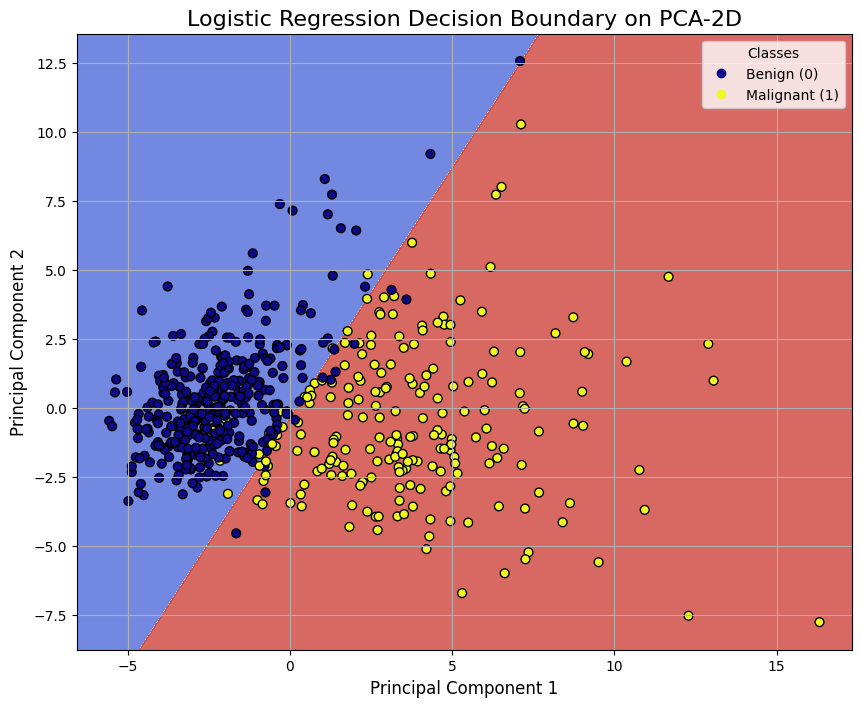

In [ ]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Import pandas for DataFrame creation

# 1. Choose Logistic Regression (one of the best performing) and re-train it on X_pca_2d
log_reg_pca_2d = LogisticRegression(random_state=42)
log_reg_pca_2d.fit(X_pca_2d, y_encoded)

# 2. Create a meshgrid to plot the decision boundaries
# Determine min and max values for PC1 and PC2 from X_pca_2d with padding
x_min, x_max = X_pca_2d['PC1'].min() - 1, X_pca_2d['PC1'].max() + 1
y_min, y_max = X_pca_2d['PC2'].min() - 1, X_pca_2d['PC2'].max() + 1

h = .02 # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Flatten grid points and combine them for prediction
meshgrid_points_array = np.c_[xx.ravel(), yy.ravel()]

# Convert meshgrid_points to DataFrame with feature names to avoid UserWarning
meshgrid_points_df = pd.DataFrame(meshgrid_points_array, columns=['PC1', 'PC2'])

# 3. Predict the class labels for each point in the meshgrid
Z = log_reg_pca_2d.predict(meshgrid_points_df)
Z = Z.reshape(xx.shape)

# 4. Create a contour plot of the decision boundaries
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

# 5. Create a scatter plot of the actual X_pca_2d points
scatter = plt.scatter(X_pca_2d['PC1'], X_pca_2d['PC2'], c=y_encoded, cmap=plt.cm.plasma, s=40, edgecolors='k')

# 6. Add labels and title
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.title('Logistic Regression Decision Boundary on PCA-2D', fontsize=16)

# 7. Include a legend to distinguish between classes
# Create custom legend handles and labels
handles, labels = scatter.legend_elements()
legend_labels = ['Benign (0)', 'Malignant (1)']
plt.legend(handles, legend_labels, title="Classes")

plt.grid(True)
plt.show()

## Final Task

### Subtask:
Summarize the findings from the feature analysis, PCA impact, model performance comparison, and insights gained from the decision boundary visualizations.


## Summary:

### Data Analysis Key Findings

*   **Data Preparation**: The breast cancer dataset was successfully loaded, and irrelevant columns ('id', 'Unnamed: 32') were removed. The categorical 'diagnosis' target variable was encoded into numerical format ('Malignant': 1, 'Benign': 0).
*   **Feature Normalization and Correlation**: All features were successfully normalized using `StandardScaler`, and their pairwise correlations were visualized using a heatmap, revealing relationships between the features.
*   **Dimensionality Reduction with PCA**:
    *   Principal Component Analysis (PCA) successfully reduced the feature space. It was determined that **10 principal components** explain **95%** of the total variance in the dataset, significantly reducing the original 30 features.
    *   Two PCA-transformed datasets were created: one with 10 components (`X_pca_high_variance`) for general modeling and another with 2 components (`X_pca_2d`) specifically for visualization.
*   **Model Performance (Full Features vs. PCA-Reduced Features)**:
    *   **Full Features**: Support Vector Machine (SVM) and Logistic Regression models showed excellent performance with an Accuracy of approximately **0.9737**, outperforming K-Nearest Neighbors (KNN) which achieved an Accuracy of **0.9474**.
    *   **PCA-Reduced Features (10 components)**:
        *   Logistic Regression saw a slight performance *increase*, achieving an Accuracy of **0.9825**.
        *   SVM maintained its high performance with an Accuracy of **0.9737**.
        *   KNN also experienced a slight improvement to an Accuracy of **0.9561**.
    *   Overall, using PCA-reduced features (10 components) did not degrade model performance; in fact, Logistic Regression and KNN showed minor improvements, while SVM maintained its high performance.
*   **Decision Boundary Visualization**: The decision boundary for Logistic Regression was successfully visualized using the 2D PCA projection of the data. This visualization clearly showed how the model separates the 'Benign' and 'Malignant' classes in the reduced feature space.

### Insights or Next Steps

*   PCA is highly effective for this dataset, allowing for a substantial reduction in feature dimensionality (from 30 to 10 components) without compromising, and in some cases slightly improving, classification performance. This suggests significant redundancy or multicollinearity among the original features.
*   Logistic Regression and SVM consistently demonstrated strong performance, making them suitable models for breast cancer diagnosis based on this dataset. Their high accuracy with fewer features could lead to more efficient and potentially robust models.
